# Crumblr — Compositional Differential Abundance

Uses **crumblr** (CLR + dream mixed-effects) as an alternative to scCODA.  
Same dataset, same tissue × annotation-level grid.

**Setup (one-time):** `bash /home/gdallagl/myworkdir/XDP/data/crumblr/crumblr/setup_env.sh`  
**Kernel:** any env with `scanpy` + `pandas` (e.g. `python3`/`.venv`) — crumblr runs in its own venv via subprocess.

In [11]:
%load_ext autoreload
%autoreload 2

import os, subprocess, json, glob
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, Image
import numpy as np
import seaborn as sns

from utils import preprocessing

# ── Paths ─────────────────────────────────────────────────────────────────────
TISSUE = "Striatum" # "Striatum" / "SN" / "DFC"
if TISSUE == "Striatum":
    ADATA          = f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/adatas/{TISSUE}/{TISSUE}_combined_QC_mmc_ct-cured_zoned.h5ad"
elif (TISSUE == "SN") | (TISSUE == "DFC"):
    ADATA          = f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/adatas/{TISSUE}/{TISSUE}_combined_QC_mmc_ct-cured.h5ad"

TISSUE         =  ADATA.split("/")[-2]
SAVE_FOLDER    = f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/compositional/crumblr/{TISSUE}"
CRUMBLR_SCRIPT = "/home/gdallagl/myworkdir/XDP/data/crumblr/crumblr/run_workflow.py"
MAPPING_JSON   = "/home/gdallagl/myworkdir/XDP/utils/STR_cell_types_annotation/group_level_mmc_mapping.json"

# ── Study design ──────────────────────────────────────────────────────────────
SAMPLE_COL     = "donor_id"
CONTRAST_COL   = "condition"
CONTRAST_REF   = "Control"
CONTRAST_STIM  = "XDP"
FIXED_EFFECTS  = ["sex", "cohort", "age_of_death"]  # fixed covariates
RANDOM_EFFECTS = []  # donor_id can't be a random effect: 1 sample per donor after aggregation → use lmFit

os.makedirs(SAVE_FOLDER, exist_ok=True)

print(TISSUE)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Striatum


In [12]:
adata = sc.read_h5ad(ADATA, backed="r")
print(adata)
print("Cell counts by tissue:", adata.obs["tissue"].value_counts().to_dict())

KeyboardInterrupt: 

In [ ]:
# Remove bad cell types 
adata = adata[~adata.obs["ct_for_deg"].str.startswith("-")].to_memory().copy()

# Remove cell types wiht too few samples
cell_type_counts = adata.obs["ct_for_deg"].value_counts()
cell_types_to_keep = cell_type_counts[cell_type_counts >= 10].index
adata = adata[adata.obs["ct_for_deg"].isin(cell_types_to_keep)].copy()

## Helper functions

In [ ]:
import sys
sys.path.insert(0, "/home/gdallagl/myworkdir/XDP/data/crumblr")  # directory, not file path
from plot_crumblr import plot_all as _plot_all

# Columns that every CSV needs (cell-type col is added separately per run)
META_COLS = [SAMPLE_COL, CONTRAST_COL, *FIXED_EFFECTS]

# Subprocess env: override the Jupyter inline backend (invalid outside Jupyter)
_SUBPROCESS_ENV = {**os.environ, "MPLBACKEND": "Agg"}


def drop_bad_samples(adata):
    """Remove donors with any missing covariate."""
    bad = {s for col in META_COLS
              for s in adata.obs[adata.obs[col].isna()][SAMPLE_COL].unique()}
    return adata[~adata.obs[SAMPLE_COL].isin(bad)]

def filter_rare_celltypes(adata, ct_col, min_samples=5, min_cells_per_sample=3):
    """Remove cell types present in too few donors (would break lmFit)."""
    counts = (
        adata.obs[[ct_col, SAMPLE_COL]]
        .groupby([ct_col, SAMPLE_COL])
        .size()
        .reset_index(name="n_cells")
    )
    donor_counts = (
        counts[counts["n_cells"] >= min_cells_per_sample]
        .groupby(ct_col)[SAMPLE_COL]
        .nunique()
    )
    keep = donor_counts[donor_counts >= min_samples].index
    removed = set(adata.obs[ct_col].unique()) - set(keep)
    if removed:
        print(f"  removing {len(removed)} rare type(s): {sorted(removed)}")
    return adata[adata.obs[ct_col].isin(keep)]

def run_crumblr(adata_sub, ct_col, output_dir, label="", show=False):
    """
    Exports CSV → calls run_workflow.py → calls plot_crumblr.py → returns results

    Export a cell-level CSV, call run_workflow.py, then plot results with plot_crumblr.py.
    All CSVs + original PDFs/PNGs are saved to output_dir by run_workflow.py.
    Custom plots saved to output_dir/images/ by plot_crumblr.py.
    Returns the results DataFrame (one row per cell type × coefficient).
    """
    os.makedirs(output_dir, exist_ok=True)
    csv_path = os.path.join(output_dir, "cells.csv")

    # Write cell-level CSV (one row per cell, columns = ct + metadata)
    df = adata_sub.obs[[ct_col, *META_COLS]].dropna().copy()
    df[ct_col] = df[ct_col].astype(str)
    df.to_csv(csv_path, index=False)

    cmd = [
        "python", CRUMBLR_SCRIPT,
        "--csv",            csv_path,
        "--proportion-col", ct_col,
        "--sample-col",     SAMPLE_COL,   # one sample per donor → same as donor-col
        "--donor-col",      SAMPLE_COL,
        "--contrast",       CONTRAST_COL,
        "--ref-level",      CONTRAST_REF,
        "--output-dir",     output_dir,
        "--fixed-effects",  *FIXED_EFFECTS,
        "--random-effects", *RANDOM_EFFECTS,
    ]
    result = subprocess.run(cmd, capture_output=True, text=True, env=_SUBPROCESS_ENV)
    print(result.stdout[-2000:])  # trim output to avoid flooding the notebook
    if result.returncode != 0:
        print("STDERR:", result.stderr[-2000:])
        raise RuntimeError(f"crumblr failed → {output_dir}")

    # Custom plots: use actual cell type names, no internal class mapping
    _plot_all(output_dir, contrast_col=CONTRAST_COL, contrast_stim=CONTRAST_STIM, label=label, show=show)

    return pd.read_csv(os.path.join(output_dir, "crumblr_results.csv"))


def run_crumblr_grid(adata, annotation_levels, out_dir, show=False):
    """Run crumblr for every annotation level on the tissue adata."""

    # remove samples with nan in some metadata
    adata = drop_bad_samples(adata).to_memory().copy()

    df_list = []
    for ct_col in annotation_levels:
        
        label = f"{TISSUE} | {ct_col}"
        print(f"\n{'='*60}\n{label}")
        #print(adata.obs[ct_col].value_counts())

        # remove ct with too few cells or samples
        adata_ct = filter_rare_celltypes(adata, ct_col, min_samples=5, min_cells_per_sample=3)

        ct_out_dir = f"{out_dir}/{ct_col}"
        df = run_crumblr(adata_ct, ct_col, ct_out_dir, label=label, show=show)
        df["tissue"]     = TISSUE
        df["annotation"] = ct_col
        df_list.append(df)

    merged = pd.concat(df_list, ignore_index=True)
    merged.to_csv(f"{out_dir}/merged_results.csv", index=False)
    return merged

## All cells

using all cells, for each annotation granularity level.

### *) create cols for zones in striatum

Right now we have one col with zone share acvross all cell types, we need a single col per ct.

In [ ]:
ZONE_CT_MAP = {
    "Matrix_D1": "zone", # just zone for zone_6
    "Matrix_D2": "zone",

    "Patch_D1":  "zone_4",
    "Patch_D2":  "zone_4",
    "eMSN_D1D2": "zone_4",
    "Astrocyte": "zone_4",
}


zone_by_Matrix_D1


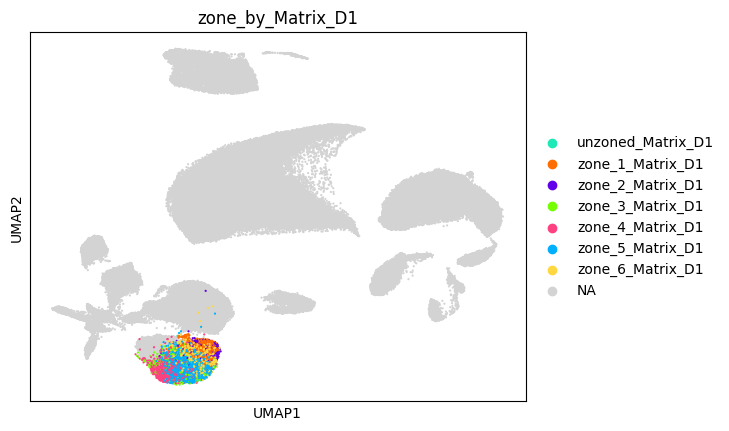


zone_by_Matrix_D2


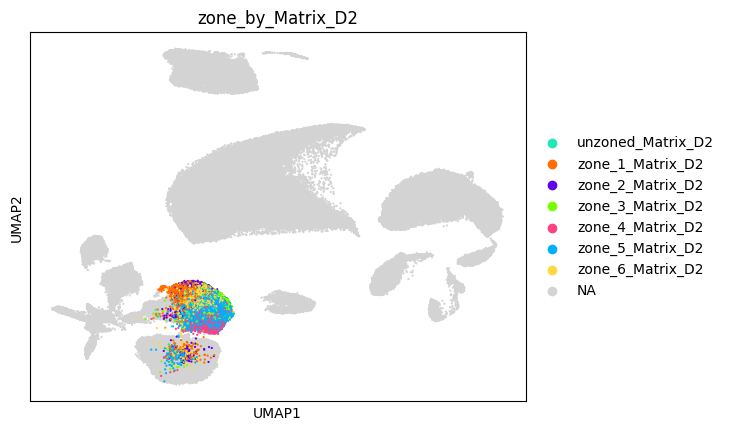


zone_4_by_Patch_D1


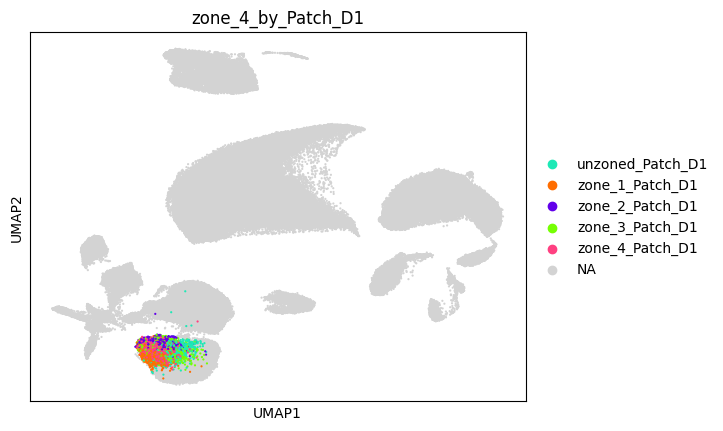


zone_4_by_Patch_D2


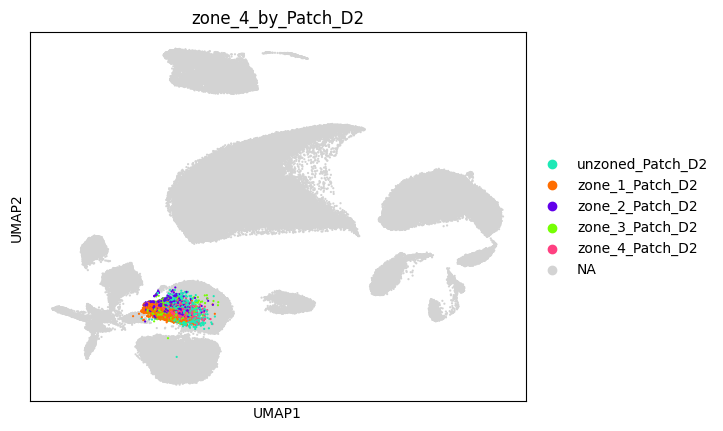


zone_4_by_eMSN_D1D2


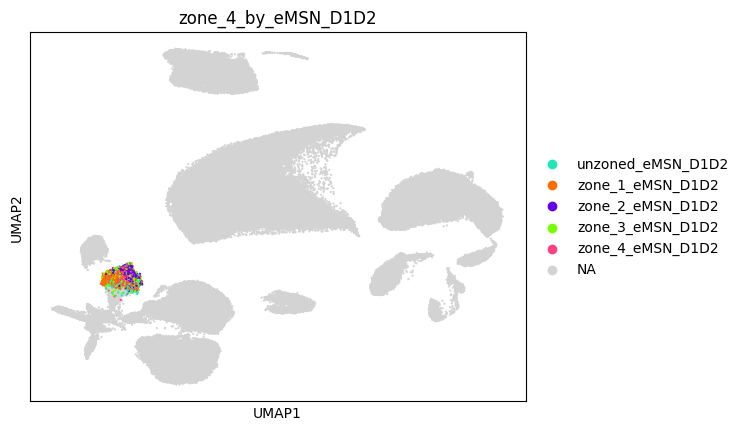


zone_4_by_Astrocyte


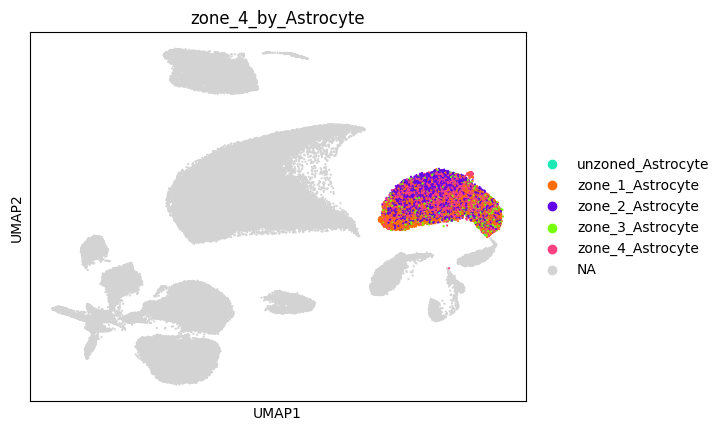

In [ ]:
if TISSUE == "Striatum":
    col_zoning = []   # will collect the names of all new columns created

    for zone_ct, zone_variable in ZONE_CT_MAP.items():

        if zone_variable not in adata.obs.columns:
            print(f"WARNING: {zone_variable} not in adata, skipping {zone_ct}")
            continue

        zone_col = f"{zone_variable}_by_{zone_ct}"
        mask = adata.obs["ct_for_deg"] == zone_ct

        # Default: every cell keeps its ct_for_deg label
        adata.obs[zone_col] = adata.obs["ct_for_deg"].astype(str)

        # Create new column
        # Cells with a zone → "zone_<N>_<CT>"
        valid_mask = mask & adata.obs[zone_variable].notna() # are this cell type AND have a zone assignment (not Na)
        adata.obs.loc[valid_mask, zone_col] = (
            "zone_" + adata.obs.loc[valid_mask, zone_variable].astype(str)
            + "_" + zone_ct
        ) # five values to new col:  eg "zone_1_Matrix_D1" or just "orign ct type"

        # Save the zone name sof his col for plotting
        zones_names = adata.obs.loc[valid_mask, zone_col].unique().tolist()

        # Cells in this CT but without zone assignment 
        unzoned_label = "unzoned_" + zone_ct
        adata.obs.loc[mask & adata.obs[zone_variable].isna(), zone_col] = unzoned_label

        print(f"\n{zone_col}")
        #print(adata.obs[zone_col].value_counts())
        col_zoning.append(zone_col)

        sc.pl.umap(adata, color=zone_col,
                   groups=[*zones_names, zone_ct, unzoned_label],
                   size=10, title=zone_col, palette=preprocessing.custom_palette)


In [14]:
LEVELS_ALL = ["ct_for_deg"]

if TISSUE == "Striatum":
    LEVELS_ALL = LEVELS_ALL + col_zoning # Only Striatum has zones
    LEVELS_ALL = LEVELS_ALL + ["Class_name", "Subclass_name", "Group_name"] # only stritum has atals for all ct

print("Annotation levels:", LEVELS_ALL)

df_all = run_crumblr_grid(adata, annotation_levels=LEVELS_ALL, out_dir = f"{SAVE_FOLDER}/all_cells", show=False)
df_all.head()

Annotation levels: ['ct_for_deg']

DFC | ct_for_deg


/tmp/ipykernel_3041149/1416857194.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([ct_col, SAMPLE_COL])
/tmp/ipykernel_3041149/1416857194.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(ct_col)[SAMPLE_COL]


[1/6] Loading /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/compositional/crumblr/DFC/all_cells/ct_for_deg/cells.csv …
[2/6] Aggregating cell counts …
  Contrast 'condition' detected as categorical.
  Samples: 44  |  Cell types: 28
[3/6] Formula: ~ condition + sex + cohort + age_of_death
[4/6] Running crumblr (R) …

[R] /home/gdallagl/myworkdir/XDP/data/crumblr/micromamba_root/envs/crumblr/bin/Rscript … formula='~ condition + sex + cohort + age_of_death'
── Loading data ────────────────────────────────────────────────────────
  Samples: 44  |  Cell types: 28
  Formula: ~ condition + sex + cohort + age_of_death
  Contrast variable: condition
── Running crumblr ─────────────────────────────────────────────────────
── Fitting dream model ─────────────────────────────────────────────────
── Extracting results ──────────────────────────────────────────────────
  Test coefficients: conditionXDP 
── Generating R plots ──────────────────────────────────────────────────
── Done.  Results written

,logFC,AveExpr,t,P.Value,adj.P.Val,B,cell_type,coefficient,tissue,annotation
0,0.046743,1.915788,0.446778,0.657314,0.766866,-5.341481,Astrocyte,conditionXDP,DFC,ct_for_deg
1,-0.136807,-2.362030,-0.843269,0.403820,0.565348,-5.164730,COP,conditionXDP,DFC,ct_for_deg
2,-0.023005,-0.577907,-0.265067,0.792245,0.853187,-5.280598,Chandelier,conditionXDP,DFC,ct_for_deg
3,-0.329096,-1.481180,-1.875101,0.067692,0.371205,-4.059962,Endothelial_BBB,conditionXDP,DFC,ct_for_deg
4,0.128216,2.644782,1.223705,0.227835,0.513115,-4.778739,L2/3 IT,conditionXDP,DFC,ct_for_deg


## Neurons only

Exclude non-neuronal cells. Groups not in the JSON mapping are labelled `NON_MSN` (the reference category).

In [15]:
#filter onyl neruons
adata_n = adata[adata.obs["is_neuron"]].to_memory().copy()

In [16]:
LEVELS_NEURONS = ["ct_for_deg"]

if TISSUE == "Striatum":
    LEVELS_NEURONS = LEVELS_NEURONS + ["Class_name", "Subclass_name", "Group_name"] # only stritum has atals for all ct
elif TISSUE == "DFC":
    LEVELS_NEURONS = LEVELS_NEURONS + ["DFC_Group_name", "DFC_Subclass_name"] # only DFC has atals for neurons at class and subclass level
elif TISSUE == "SN":
    LEVELS_NEURONS = LEVELS_NEURONS + ["SN_Group_name", "SN_Subclass_name"] # only Hippocampus has atals for neurons at class and subclass level

print("Annotation levels:", LEVELS_NEURONS)

df_neurons = run_crumblr_grid(adata_n, annotation_levels=LEVELS_NEURONS, out_dir = f"{SAVE_FOLDER}/only_neurons", show=False)
df_neurons.head()

del adata_n

Annotation levels: ['ct_for_deg', 'DFC_Group_name', 'DFC_Subclass_name']



DFC | ct_for_deg


/tmp/ipykernel_3041149/1416857194.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([ct_col, SAMPLE_COL])
/tmp/ipykernel_3041149/1416857194.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(ct_col)[SAMPLE_COL]


[1/6] Loading /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/compositional/crumblr/DFC/only_neurons/ct_for_deg/cells.csv …
[2/6] Aggregating cell counts …
  Contrast 'condition' detected as categorical.
  Samples: 44  |  Cell types: 20
[3/6] Formula: ~ condition + sex + cohort + age_of_death
[4/6] Running crumblr (R) …

[R] /home/gdallagl/myworkdir/XDP/data/crumblr/micromamba_root/envs/crumblr/bin/Rscript … formula='~ condition + sex + cohort + age_of_death'
── Loading data ────────────────────────────────────────────────────────
  Samples: 44  |  Cell types: 20
  Formula: ~ condition + sex + cohort + age_of_death
  Contrast variable: condition
── Running crumblr ─────────────────────────────────────────────────────
── Fitting dream model ─────────────────────────────────────────────────
── Extracting results ──────────────────────────────────────────────────
  Test coefficients: conditionXDP 
── Generating R plots ──────────────────────────────────────────────────
── Done.  Results writ

/tmp/ipykernel_3041149/1416857194.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([ct_col, SAMPLE_COL])
/tmp/ipykernel_3041149/1416857194.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(ct_col)[SAMPLE_COL]


[1/6] Loading /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/compositional/crumblr/DFC/only_neurons/DFC_Group_name/cells.csv …
[2/6] Aggregating cell counts …
  Contrast 'condition' detected as categorical.
  Samples: 44  |  Cell types: 82
[3/6] Formula: ~ condition + sex + cohort + age_of_death
[4/6] Running crumblr (R) …

[R] /home/gdallagl/myworkdir/XDP/data/crumblr/micromamba_root/envs/crumblr/bin/Rscript … formula='~ condition + sex + cohort + age_of_death'
── Loading data ────────────────────────────────────────────────────────
  Samples: 44  |  Cell types: 82
  Formula: ~ condition + sex + cohort + age_of_death
  Contrast variable: condition
── Running crumblr ─────────────────────────────────────────────────────
── Fitting dream model ─────────────────────────────────────────────────
── Extracting results ──────────────────────────────────────────────────
  Test coefficients: conditionXDP 
── Generating R plots ──────────────────────────────────────────────────
── Done.  Results 

/home/gdallagl/myworkdir/XDP/data/crumblr/plot_crumblr.py:255: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()



DFC | DFC_Subclass_name
  removing 1 rare type(s): ['Sst Chodl']


/tmp/ipykernel_3041149/1416857194.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([ct_col, SAMPLE_COL])
/tmp/ipykernel_3041149/1416857194.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(ct_col)[SAMPLE_COL]


[1/6] Loading /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/compositional/crumblr/DFC/only_neurons/DFC_Subclass_name/cells.csv …
[2/6] Aggregating cell counts …
  Contrast 'condition' detected as categorical.
  Samples: 44  |  Cell types: 16
[3/6] Formula: ~ condition + sex + cohort + age_of_death
[4/6] Running crumblr (R) …

[R] /home/gdallagl/myworkdir/XDP/data/crumblr/micromamba_root/envs/crumblr/bin/Rscript … formula='~ condition + sex + cohort + age_of_death'
── Loading data ────────────────────────────────────────────────────────
  Samples: 44  |  Cell types: 16
  Formula: ~ condition + sex + cohort + age_of_death
  Contrast variable: condition
── Running crumblr ─────────────────────────────────────────────────────
── Fitting dream model ─────────────────────────────────────────────────
── Extracting results ──────────────────────────────────────────────────
  Test coefficients: conditionXDP 
── Generating R plots ──────────────────────────────────────────────────
── Done.  Resul

# Zones - Striatum - Only specific cell type

- drop unzoned cell
- RECREATE zone columns for each cell type (differt col form before)

In [ ]:
if TISSUE == "Striatum":

    df_zones_list = []

    for zone_ct, zone_variable in ZONE_CT_MAP.items():

        print(f"\n{zone_variable} | {zone_ct}")

        # subset to this CT (the one used for the zoningn !); drop bad donors; drop unzoned cells
        adata_sub = adata[adata.obs["ct_for_deg"] == zone_ct].to_memory().copy()
        adata_sub = drop_bad_samples(adata_sub).copy()
        adata_sub = adata_sub[adata_sub.obs[zone_variable].notna()].copy() # drop unzoned cells

        # Create new col label
        adata_sub.obs["zone_labeled"] = "zone_" + adata_sub.obs[zone_variable].astype(str) # eg "zone_1"
        print(adata_sub.obs["zone_labeled"].value_counts())

        # create saving folder
        safe_name = zone_ct.replace(" ", "_").replace("/", "-")
        out_dir = f"{SAVE_FOLDER}/only_zone/{zone_variable}/{safe_name}"

        try:
            df = run_crumblr(adata_sub, "zone_labeled", out_dir,
                             label=f"{zone_variable} | {zone_ct}", show=False)
            
            # add run info
            df["ct_used_for_zoning"] = zone_ct
            df["zone_col"]           = zone_variable

            df_zones_list.append(df)
            
        except RuntimeError as e:
            print(f"  skipping (crumblr failed): {e}")
            continue

    df_zones_per_ct = pd.concat(df_zones_list, ignore_index=True)
    df_zones_per_ct["annotation"] = df_zones_per_ct["zone_col"]
    df_zones_per_ct["tissue"] = TISSUE
    df_zones_per_ct.to_csv(f"{SAVE_FOLDER}/only_zone/all_results.csv", index=False)
    df_zones_per_ct



zone | Matrix_D1
zone_labeled
zone_5    2775
zone_2    1899
zone_3    1826
zone_6    1759
zone_1    1440
zone_4    1293
Name: count, dtype: int64
ec/compositional/crumblr/Striatum/only_zone/zone/Matrix_D1/cells.csv …
[2/6] Aggregating cell counts …
  Dropping 14 sample(s) with < 100 cells: ['PCMC-16-012', 'SCF-18-004', 'SCF-21-030', 'SCF_20-026', 'SCF_21_027', 'SCF_21_029', 'SCF_21_032', 'SCF_21_034', 'SCF_21_038', 'SCF_22-043', 'SCF_22-060', 'SCF_23-080', 'SCF_23-083', 'SCF_23_070_MMC']
  Contrast 'condition' detected as categorical.
  Samples: 33  |  Cell types: 6
[3/6] Formula: ~ condition + sex + cohort + age_of_death
[4/6] Running crumblr (R) …

[R] /home/gdallagl/myworkdir/XDP/data/crumblr/micromamba_root/envs/crumblr/bin/Rscript … formula='~ condition + sex + cohort + age_of_death'
── Loading data ────────────────────────────────────────────────────────
  Samples: 33  |  Cell types: 6
  Formula: ~ condition + sex + cohort + age_of_death
  Contrast variable: condition
── Running

In [2]:
# if TISSUE == "Striatum":
#     df_zones_list = []

#     # loop over both zoning schemes (6-zone and 4-zone)
#     for col_coupling, col_zones in [("mapping_coupling_for_zoning", "zone"), ("mapping_coupling_for_zoning_4_zones", "zone_4")]:
#         for ct_used_for_zoning in adata.obs[col_coupling].unique().tolist():

#             # skip NaN entries and cell types where all zone values are NaN
#             if pd.isna(ct_used_for_zoning) or adata.obs.loc[adata.obs[col_coupling] == ct_used_for_zoning, col_zones].isna().all():
#                 continue

#             # cell types that borrow their zone assignments from ct_used_for_zoning
#             groups = adata.obs.loc[adata.obs[col_coupling] == ct_used_for_zoning, "Group_name"].unique().tolist()
#             print(f"\n{col_zones} | {ct_used_for_zoning} → {groups}")

#             # subset to this cell type only; remove donors with missing covariates; drop unzoned cells
#             adata_sub = adata[adata.obs["Group_name"].isin(groups)].to_memory().copy()
#             adata_sub = drop_bad_samples(adata_sub).copy()
#             adata_sub = adata_sub[adata_sub.obs[col_zones].notna()].copy()

#             # prefix zone numbers with "zone_" so R doesn't parse them as integers
#             adata_sub.obs["zone_labeled"] = "zone_" + adata_sub.obs[col_zones].astype(str)
#             print(adata_sub.obs["zone_labeled"].value_counts())

#             safe_name = ct_used_for_zoning.replace(" ", "_").replace("/", "-")
#             out_dir = f"{SAVE_FOLDER}/only_zone/{col_zones}/{safe_name}"

#             try:
#                 df = run_crumblr(adata_sub, "zone_labeled", out_dir, label=f"{col_zones} | {ct_used_for_zoning}", show=False)
#                 df["ct_used_for_zoning"] = ct_used_for_zoning
#                 df["zone_col"]           = col_zones
#                 df_zones_list.append(df)
#             except RuntimeError as e:
#                 print(f"  skipping (crumblr failed): {e}")
#                 continue

#     df_zones_per_ct = pd.concat(df_zones_list, ignore_index=True)
#     df_zones_per_ct["annotation"] = df_zones_per_ct["zone_col"]
#     df_zones_per_ct["tissue"] = TISSUE
#     df_zones_per_ct.to_csv(f"{SAVE_FOLDER}/only_zone/all_results.csv", index=False)
#     df_zones_per_ct


## Summary — significant hits across all analyses

In [1]:
# UP_COLOR   = "#2ca02c"
# DOWN_COLOR = "#d62728"

# def plot_significant_summary(merged_csv, contrast_stim="XDP", fdr_thr=0.05,
#                               fontsize=9, show=True, label=""):
#     df = pd.read_csv(merged_csv)
#     df = df[df["coefficient"].str.contains(contrast_stim, na=False)].copy()
#     sig = df[df["adj.P.Val"] < fdr_thr].copy()

#     if sig.empty:
#         print("No significant hits found.")
#         return sig

#     ann_order = [a for a in ["Class_name", "Subclass_name", "Group_name", "ct_for_deg"]
#                  if a in sig["annotation"].unique()]
#     ann_order += [a for a in sig["annotation"].unique() if a not in ann_order]

#     sig["-log10FDR"] = -np.log10(sig["adj.P.Val"].clip(lower=1e-10))

#     mat_lfc = pd.DataFrame(np.nan, index=sig["cell_type"].unique(), columns=ann_order)
#     mat_fdr = pd.DataFrame(np.nan, index=sig["cell_type"].unique(), columns=ann_order)
#     for _, r in sig.iterrows():
#         mat_lfc.loc[r["cell_type"], r["annotation"]] = r["logFC"]
#         mat_fdr.loc[r["cell_type"], r["annotation"]] = r["-log10FDR"]

#     primary_ann = sig.groupby("cell_type").apply(
#         lambda x: x.loc[x["adj.P.Val"].idxmin(), "annotation"]
#     )

#     ordered_cts, group_boundaries = [], {}
#     for ann in ann_order:
#         cts = primary_ann[primary_ann == ann].index.tolist()
#         if not cts:
#             continue
#         sorted_cts = mat_lfc.loc[cts, ann].sort_values().index.tolist()
#         group_boundaries[ann] = (len(ordered_cts), len(ordered_cts) + len(sorted_cts))
#         ordered_cts.extend(sorted_cts)

#     mat_lfc = mat_lfc.loc[ordered_cts]
#     mat_fdr = mat_fdr.loc[ordered_cts]

#     # cell types on X, annotation levels on Y
#     n_cols = len(ordered_cts)   # cell types
#     n_rows = len(ann_order)     # annotation levels
#     vmax   = sig["logFC"].abs().max()
#     group_colors = dict(zip(ann_order, sns.color_palette("tab10", len(ann_order))))

#     fig, (ax, ax_bar) = plt.subplots(
#         2, 1,
#         figsize=(n_cols * 0.45 + 3.5, n_rows * 0.7 + 2.5),
#         gridspec_kw={"height_ratios": [n_rows, 0.3], "hspace": 0.02},
#     )
#     fig.subplots_adjust(bottom=0.02)

#     # ── Main dot plot ─────────────────────────────────────────────────────────
#     for i in range(n_rows):
#         ax.axhspan(i - 0.5, i + 0.5, color="#f5f5f5" if i % 2 == 0 else "white", zorder=0)

#     ax.set_xlim(-0.5, n_cols - 0.5)
#     ax.set_ylim(-0.5, n_rows - 0.5)

#     norm = plt.Normalize(-vmax, vmax)
#     cmap = plt.get_cmap("RdBu_r")

#     # Subtle per-column grid lines
#     for j in range(n_cols):
#         ax.axvline(j, color="#dddddd", lw=0.5, ls="-", zorder=1)

#     # Dots
#     for i, ann in enumerate(ann_order):
#         for j, ct in enumerate(ordered_cts):
#             lfc = mat_lfc.loc[ct, ann]
#             fdr = mat_fdr.loc[ct, ann]
#             if pd.isna(lfc):
#                 continue
#             ax.scatter(j, i, s=fdr * 35 + 15, color=cmap(norm(lfc)),
#                        edgecolors="black", linewidths=0.4, zorder=3)

#     # Prominent vertical group separators
#     for ann, (start, _) in group_boundaries.items():
#         if start > 0:
#             ax.axvline(start - 0.5, color="#333333", lw=2.0, ls="-", zorder=4)

#     # Y-axis: annotation levels
#     ax.set_yticks(range(n_rows))
#     ax.set_yticklabels(ann_order, fontsize=fontsize + 1)
#     ax.set_ylabel("Annotation level", fontsize=fontsize + 1)

#     # X-axis: cell type names, colored by group, on top
#     ax.set_xticks(range(n_cols))
#     ax.set_xticklabels(ordered_cts, rotation=45, ha="left", fontsize=fontsize)
#     ax.xaxis.set_ticks_position("top")
#     ax.xaxis.set_label_position("top")
#     ax.set_xlabel("Cell type", fontsize=fontsize + 1, labelpad=6)
#     ax.tick_params(length=0)
#     for tick, ct in zip(ax.get_xticklabels(), ordered_cts):
#         tick.set_color(group_colors[primary_ann[ct]])
#         tick.set_fontweight("bold")

#     # ── Bottom colored group strip ────────────────────────────────────────────
#     ax_bar.set_xlim(-0.5, n_cols - 0.5)
#     ax_bar.set_ylim(0, 1)
#     ax_bar.axis("off")

#     for ann, (start, end) in group_boundaries.items():
#         ax_bar.add_patch(plt.Rectangle(
#             (start - 0.5, 0.1), end - start, 0.8,
#             color=group_colors[ann], alpha=0.85, zorder=2
#         ))
#         mid = (start + end) / 2 - 0.5
#         ax_bar.text(mid, -0.15, ann,
#                     ha="left", va="top",
#                     fontsize=fontsize - 1, fontweight="bold", color=group_colors[ann],
#                     rotation=-30, clip_on=False, zorder=3)
#         if start > 0:
#             ax_bar.axvline(start - 0.5, color="#333333", lw=2.0, ls="-", zorder=4)

#     # ── Colorbar ──────────────────────────────────────────────────────────────
#     sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
#     sm.set_array([])
#     cax = fig.add_axes([1.01, 0.35, 0.02, 0.45],
#                        transform=ax.transAxes)
#     cb  = fig.colorbar(sm, cax=cax)
#     cb.ax.tick_params(labelsize=fontsize - 1)
#     cb.set_label("log2FC (CLR)", fontsize=fontsize)

#     # ── Size legend ───────────────────────────────────────────────────────────
#     for fdr_val, lbl in [(0.05, "0.05"), (0.01, "0.01"), (0.001, "0.001")]:
#         ax.scatter([], [], s=-np.log10(fdr_val) * 35 + 15, color="grey",
#                    edgecolors="black", linewidths=0.4, label=f"FDR = {lbl}")
#     ax.legend(title="FDR (dot size)", bbox_to_anchor=(1.07, 0),
#               loc="lower left", frameon=False, fontsize=fontsize - 1)

#     ax.set_title(f"Significant DA — {contrast_stim}  (FDR < {fdr_thr})  {label}",
#                  fontsize=fontsize + 2, fontweight="bold", pad=35)

#     out = os.path.join(os.path.dirname(merged_csv), f"significant_summary_{contrast_stim}.png")
#     fig.savefig(out, dpi=200, bbox_inches="tight")
#     print(f"Saved: {out}")
#     plt.show() if show else plt.close(fig)
#     return sig


# # ── call it ──
# plot_significant_summary(
#     "/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/compositional/crumblr/Striatum/all_cells/merged_results.csv",
#     contrast_stim=CONTRAST_STIM,
#     label=f"{TISSUE} | all cells",
# )


It receives one merged_results.csv — a file that concatenates crumblr results across all annotation levels (Class_name, Subclass_name, Group_name, ct_for_deg).



/tmp/ipykernel_3818385/3753545762.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap("tab10", len(groups))
Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


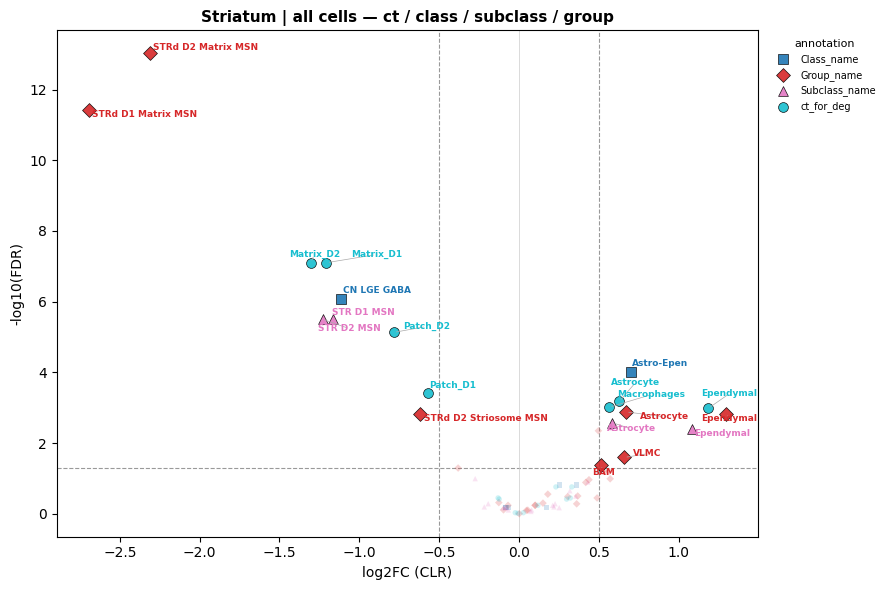

/tmp/ipykernel_3818385/3753545762.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap("tab10", len(groups))


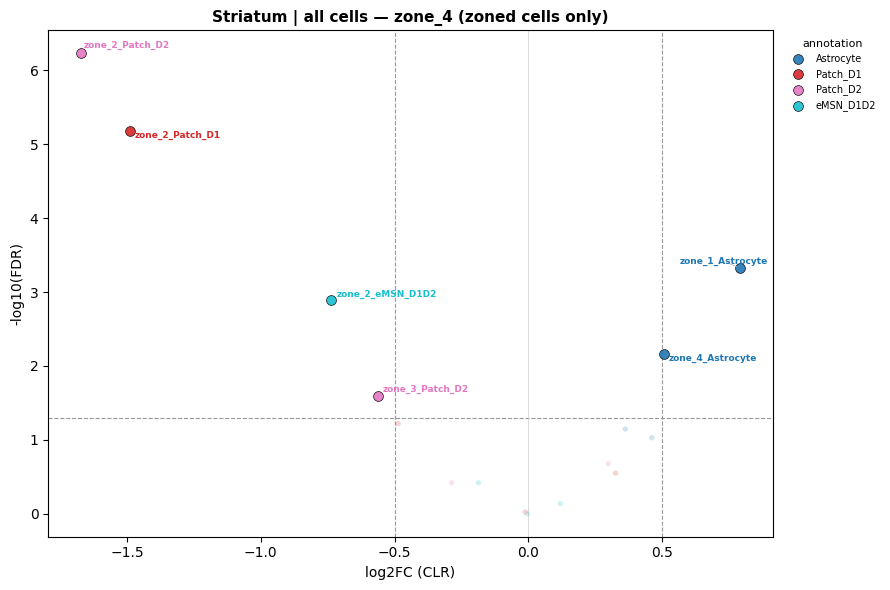

/tmp/ipykernel_3818385/3753545762.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap("tab10", len(groups))


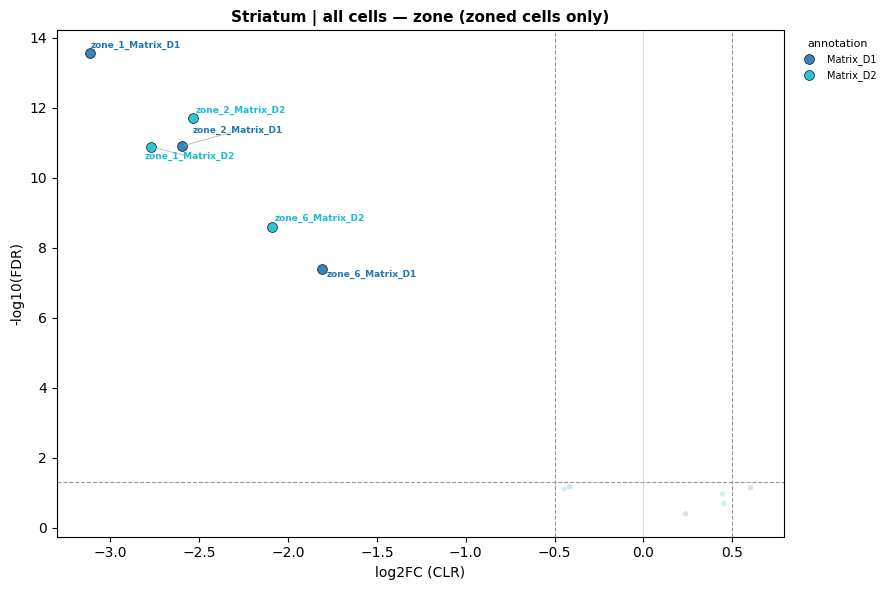

/tmp/ipykernel_3818385/3753545762.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap("tab10", len(groups))


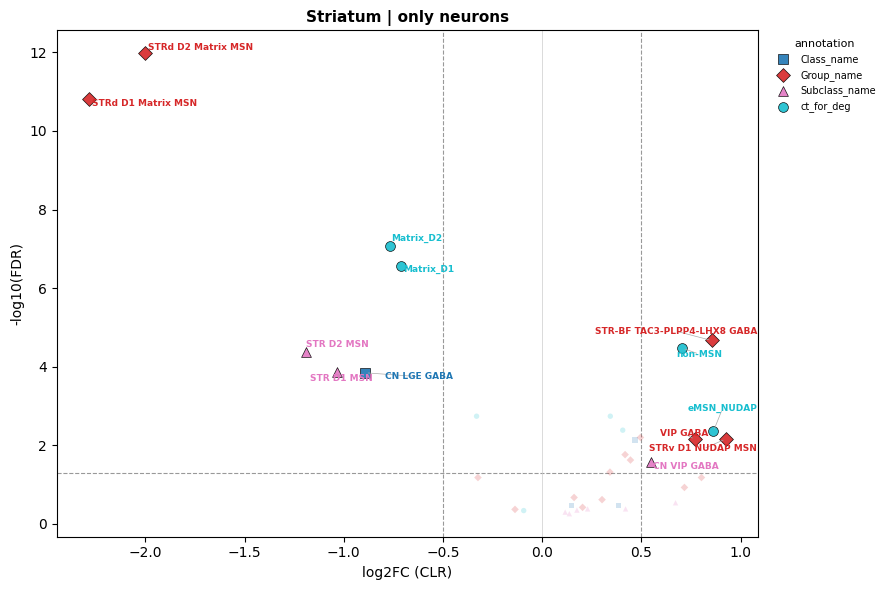

/tmp/ipykernel_3818385/3753545762.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap("tab10", len(groups))


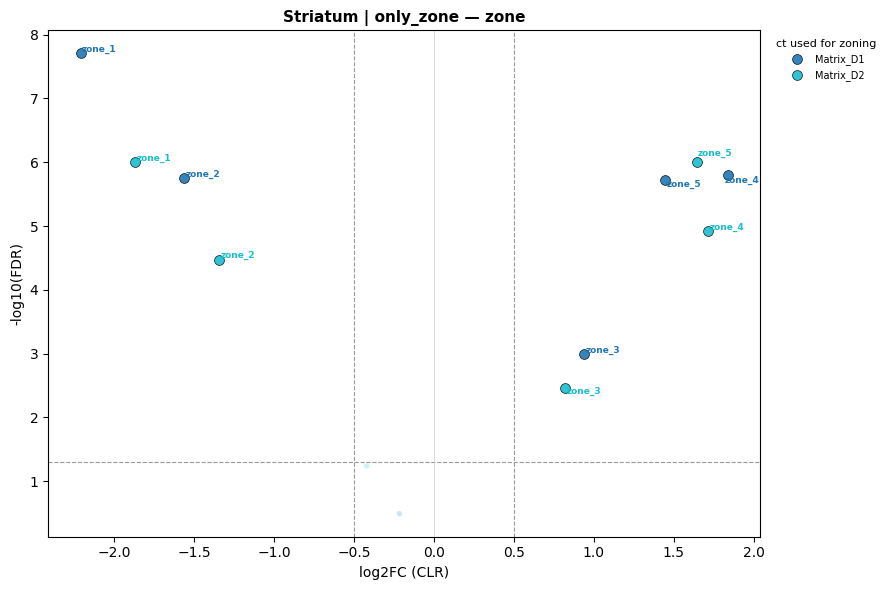

/tmp/ipykernel_3818385/3753545762.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap("tab10", len(groups))


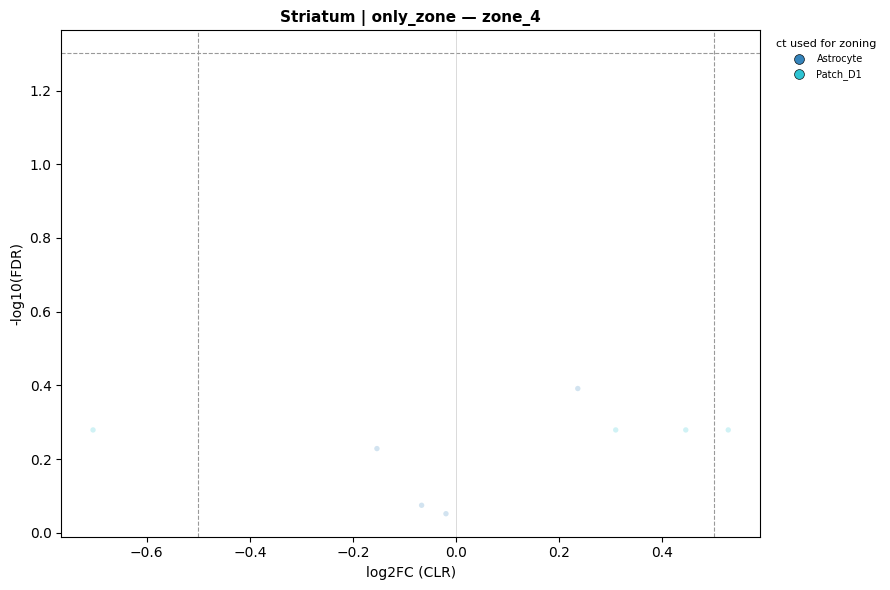

In [10]:
from adjustText import adjust_text

BASE     = SAVE_FOLDER                          # fix 1: use variable, not hardcoded path
FDR_THR  = 0.05
LFC_THR  = 0.5
CONTRAST = CONTRAST_STIM                        # fix 2: use variable, not hardcoded "XDP"

MARKERS = {"ct_for_deg": "o", "Class_name": "s", "Subclass_name": "^", "Group_name": "D"}

def volcano(df, title, save_path, color_col="annotation", label_col="cell_type",
            fdr_thr=FDR_THR, lfc_thr=LFC_THR, figsize=(9, 6)):
    df = df[df["coefficient"].str.contains(CONTRAST, na=False)].copy()
    df["-logFDR"] = -np.log10(df["adj.P.Val"].clip(1e-15))
    df["sig"] = (df["adj.P.Val"] < fdr_thr) & (df["logFC"].abs() > lfc_thr)

    groups = sorted(df[color_col].unique())
    cmap   = plt.cm.get_cmap("tab10", len(groups))
    colors = {g: cmap(i) for i, g in enumerate(groups)}

    fig, ax = plt.subplots(figsize=figsize)
    ax.axhline(-np.log10(fdr_thr), color="#999", lw=0.8, ls="--", zorder=0)
    ax.axvline( lfc_thr, color="#999", lw=0.8, ls="--", zorder=0)
    ax.axvline(-lfc_thr, color="#999", lw=0.8, ls="--", zorder=0)
    ax.axvline(0, color="#ccc", lw=0.5, zorder=0)

    texts = []
    for g, grp in df.groupby(color_col):
        c  = colors[g]
        mk = MARKERS.get(g, "o")
        ax.scatter(grp.loc[~grp["sig"], "logFC"], grp.loc[~grp["sig"], "-logFDR"],
                   s=15, marker=mk, color=c, alpha=0.2, edgecolors="none", zorder=2)
        sig = grp[grp["sig"]]
        ax.scatter(sig["logFC"], sig["-logFDR"],
                   s=50, marker=mk, color=c, alpha=0.9,
                   edgecolors="black", linewidths=0.5, zorder=3,
                   label=g.replace("zone_4_by_","").replace("zone_by_",""))  # fix 3: new col names
        for _, r in sig.iterrows():
            texts.append(ax.text(r["logFC"], r["-logFDR"], r[label_col],
                                 fontsize=6.5, color=c, fontweight="bold", zorder=4))

    if texts:
        try:
            adjust_text(texts, ax=ax,
                        arrowprops=dict(arrowstyle="-", color="#aaa", lw=0.5),
                        expand_text=(1.1, 1.3), force_text=(0.4, 0.6))
        except Exception:
            pass

    ax.set_xlabel("log2FC (CLR)", fontsize=10)
    ax.set_ylabel("-log10(FDR)", fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold")
    handles, labels = ax.get_legend_handles_labels()
    seen = dict(zip(labels, handles))
    ax.legend(seen.values(), seen.keys(), title=color_col.replace("_"," "),
              fontsize=7, title_fontsize=8,
              bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
    plt.tight_layout()
    fig.savefig(save_path)
    plt.show()


df_all  = pd.read_csv(f"{BASE}/all_cells/merged_results.csv")
df_neu  = pd.read_csv(f"{BASE}/only_neurons/merged_results.csv")

NON_ZONE = ["ct_for_deg", "Class_name", "Subclass_name", "Group_name"]

# 1. all cells — ct / class / subclass / group
volcano(df_all[df_all["annotation"].isin(NON_ZONE)],
        title=f"{TISSUE} | all cells — ct / class / subclass / group",
        save_path=f"{BASE}/all_cells/volcano_ct.png")

# 2. all cells — zone_4_by_* (zoned cells only)
_zone4 = df_all[df_all["annotation"].str.startswith("zone_4_by_")].copy()  # fix 4: new col prefix
_zone4 = _zone4[_zone4["cell_type"].str.match(r"^zone_\d+_")]               # fix 5: new label format
if not _zone4.empty:
    volcano(_zone4, title=f"{TISSUE} | all cells — zone_4 (zoned cells only)",
            save_path=f"{BASE}/all_cells/volcano_zone_4.png")

# 3. all cells — zone_by_* (zoned cells only)
_zone = df_all[df_all["annotation"].str.startswith("zone_by_")].copy()      # fix 4: new col prefix
_zone = _zone[_zone["cell_type"].str.match(r"^zone_\d+_")]                  # fix 5: new label format
if not _zone.empty:
    volcano(_zone, title=f"{TISSUE} | all cells — zone (zoned cells only)",
            save_path=f"{BASE}/all_cells/volcano_zone.png")

# 4. only neurons
volcano(df_neu, title=f"{TISSUE} | only neurons",
        save_path=f"{BASE}/only_neurons/volcano_only_neurons.png")

# 5 & 6. only_zone — zone / zone_4 (Striatum only)
_zone_path = f"{BASE}/only_zone/all_results.csv"
if os.path.exists(_zone_path):
    df_zone = pd.read_csv(_zone_path)

    volcano(df_zone[df_zone["zone_col"] == "zone"],
            title=f"{TISSUE} | only_zone — zone",
            color_col="ct_used_for_zoning",
            save_path=f"{BASE}/only_zone/volcano_zone.png")

    volcano(df_zone[df_zone["zone_col"] == "zone_4"],
            title=f"{TISSUE} | only_zone — zone_4",
            color_col="ct_used_for_zoning",
            save_path=f"{BASE}/only_zone/volcano_zone_4.png")
else:
    print(f"Skipping only_zone plots — no zone analysis found for {TISSUE}")